In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
import pandas as pd 
pd.set_option("display.max_columns", None)      # view ALL columns in DataFrames
# pd.reset_option("display.max_columns")        # reset to default
from pypalettes import load_cmap
from drawarrow import ax_arrow
from highlight_text import fig_text, ax_text
# personalisation
plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 11,
    "lines.linewidth": 1,
})

# Import Data

In [96]:
df = pd.read_parquet("../data/strava_activities.parquet")

keep = [
    "activity_id", "name", "type",
    "start_datetime", "end_datetime",
    "date", "year", "month", "week", "weekday", "start_hour",
    "distance_km", "distance_miles",
    "moving_time_mins", "elapsed_time_mins",
    "avg_pace_km", "avg_pace_mile",
    "avg_hr", "max_hr", "avg_cadence_spm",
    "total_elev_gain",
    "shoe", "num_comments", "num_achievements", "num_kudos"
]

df = df[keep]

df = (
    df.loc[df["type"] == "Run"]     # analyze running activities only
    .groupby(["year", "week"])
      .agg(
            total_distance=("distance_km", "sum"),
            activities=("activity_id", "count")
      )
      .reset_index()
)

# create a "date" column for the start of each week (Monday)
df["date"] = pd.to_datetime(
    df["year"].astype(str) + "-"
    + df["week"].astype(str) + "-1",     # Monday as first day of the week
    format="%Y-%W-%w"
    # %W - week number of the year (Monday as first day, 00-53)
    # %w - weekday as a number (0-6, Sunday=0, Saturday=6)
)

df = df[df["year"] > 2018]

df

,year,week,total_distance,activities,date
1,2019,1,19.0409,4,2019-01-07
2,2019,2,14.3965,5,2019-01-14
3,2019,3,6.9374,2,2019-01-21
4,2019,4,8.7516,2,2019-01-28
5,2019,5,12.1366,3,2019-02-04
...,...,...,...,...,...
274,2026,10,5.0365,1,2026-03-09
275,2026,11,8.5425,1,2026-03-16
276,2026,13,5.5459,1,2026-03-30
277,2026,14,17.2056,2,2026-04-06


# Scatter Graph

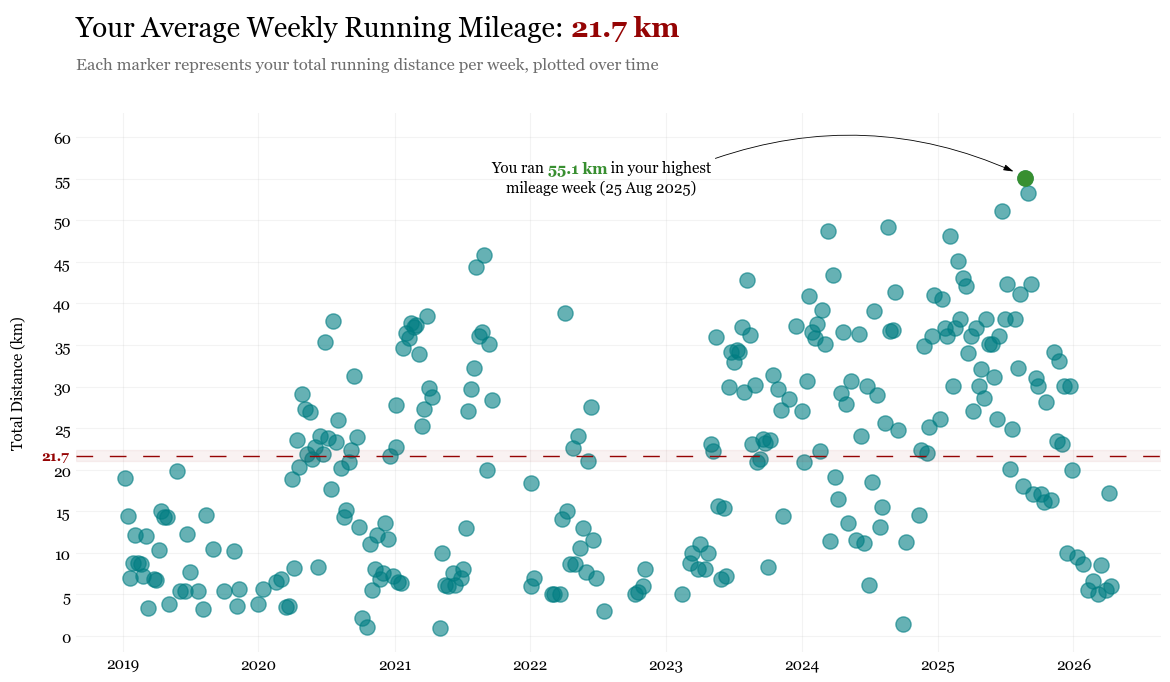

In [152]:
# colour palette
cmap = load_cmap("Abbott")
colours = cmap.colors
marker_colour = colours[6]
avg_colour = colours[0]
highlight_colour = colours[4]

# create a figure for visualisation
fig, ax = plt.subplots(figsize=(14, 7))

# axes customisation
ax.grid(True, alpha=0.15, zorder=0)
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(length=0)
ax.yaxis.set_major_locator(MaxNLocator(nbins=15))
ax.set_ylabel("Total Distance (km)", labelpad=20)

# scatter plot (weekly running distance)
marker_size = 120
ax.scatter(
    df["date"],
    df["total_distance"],
    c=marker_colour,
    edgecolors=marker_colour,
    s=marker_size,
    alpha=0.6,
    zorder=4
)

# average line
y_avg = df["total_distance"].mean()
ax.axhline(
    y=y_avg,
    linestyle=(0, (12, 12)),
    color=avg_colour,
    zorder=5
)
ax.axhspan(y_avg * 0.97, y_avg * 1.03, color=avg_colour, alpha=0.05, zorder=5)
ax.text(
    x=mdates.date2num(df["date"].min()) - 150,
    y=y_avg,
    s=f"{y_avg:.1f}",
    color=avg_colour,
    va="center",
    ha="right",
    fontsize=10,
    weight="bold"
)

# highlight max mileage week
max_week = df.loc[df["total_distance"].idxmax()]
x_max, y_max = max_week["date"], max_week["total_distance"]
ax.scatter(
    x_max,
    y_max,
    s=marker_size * 1,
    c=highlight_colour,
    zorder=5
)

# arrow
x_head, y_head = mdates.date2num(x_max), y_max
x_tail, y_tail = mdates.date2num(pd.Timestamp("2023-06-01")), y_max
ax_arrow(
    head_position=[x_head - 25, y_head + 0.6],
    tail_position=[x_tail - 25, y_tail * 1.04],
    fill_head=True,
    head_width=1.8,
    head_length=6,
    color="black",
    radius=-0.2,
    width=0.6
)

# annotation text
date_format = max_week["date"].strftime("%d %b %Y")    # format e.g. "01 Jun '22"
ax_text(
    x=x_tail - 325, y=y_tail,
    s=f"You ran <{y_max:.1f} km> in your highest\nmileage week ({date_format})",
    highlight_textprops=[
        {"color": highlight_colour, "weight": "bold"},
    ],
    fontsize=11,
    va="center",
    ha="center",
    textalign="center"
)

# title
x_value, y_value = 0.125, 1.02
fig_text(
    x=x_value,
    y=y_value,
    s=f"Your Average Weekly Running Mileage: <{y_avg:.1f} km>",
    highlight_textprops=[
        {"color": avg_colour, "weight": "bold"},
    ],
    fontsize=20
)

# subtitle
fig.text(
    x=x_value,
    y=y_value * 0.925,
    s="Each marker represents your total running distance per week, plotted over time",
    size=12,
    color="#6e6e6e"
)

plt.savefig("../images/weekly_running_distance.svg", bbox_inches="tight")

plt.show()